In [1]:
import sys
import math
import zipfile
import scipy as sp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import scipy.signal as ss
import matplotlib.pyplot as plt

from numpy.linalg import lstsq
from matplotlib.lines import Line2D

In [3]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
sys.path.append('/content/drive/MyDrive/Chapman/Research/RADAR/classes')

Mounted at /content/drive


In [10]:
import waves

## my code

##### load in libraries

In [11]:
# fit the superfunction with a smaller bandwidth to the sinc
# since we know the sinc has a bandwidth of 10, we can find cosine frequencies
# maxing at half this amount

# Define the Fourier series function using only cosine terms
def fourier_series(t, coefficients, fmin, fmax, make_complex=False):
    result = np.zeros(len(t))
    N = len(coefficients)
    dw = (fmax-fmin)/(N-1)
    if make_complex:
        result = np.zeros(len(t), dtype=np.complex128)
        for k in range(0, N):
            result += coefficients[k] * np.exp(1j*2*np.pi*t*(fmin+(dw*k)))
    else:
        for k in range(0, N):
            result += coefficients[k] * np.cos(2*np.pi*t*(fmin+(dw*k)))
    return result

# Construct the design matrix
def get_fourier_fit(t, N, fmin, fmax):
    dw = (fmax-fmin)/(N-1)
    A = np.zeros((len(t), N))
    for k in range(0, N):
        A[:, k] = np.cos(2*np.pi*t*(fmin+(dw*k)))
    return A

# Construct the design matrix
def get_fourier_fit_odd(t, N, fmin, fmax):
    dw = (fmax-fmin)/(N-1)
    A = np.zeros((len(t), N))
    for k in range(0, N):
        A[:, k] = np.sin(2*np.pi*t*(fmin+(dw*k)))
    return A

def dlog(wave):
    return np.diff(np.log(wave))

#### creating the wave

##### create wave to fit to

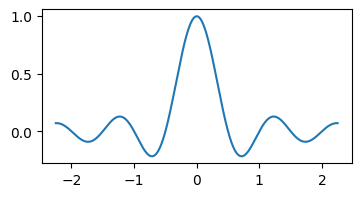

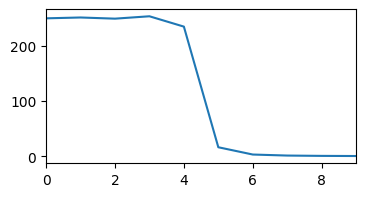

In [12]:
# create the sinc we will fit to. this sinc clearly has an inverse bandwidth of .1*{window size}

_sincwidth  = 4.5
_sinclength = 2250
invbw       = _sinclength/_sincwidth

_t = np.linspace(-_sincwidth/2, _sincwidth/2, _sinclength)
_sinc = np.sin(_t*np.pi*2)/(_t*np.pi*2)
# _sinc = np.cos(_t*np.pi*2)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (4,2)
plt.plot(_t, _sinc)
plt.show()

plt.plot(np.abs(np.fft.fft(_sinc)))
plt.xlim(0,_sincwidth*2)
plt.show()

##### find the best fit

In [ ]:
results = []    # N, Omega, omega_min, max amp, MSE
for N in np.arange(3, 11):
    print('N =', N)
    for freqspread in np.arange(.1, .51, .05):
        print('  freqspread =', round(freqspread,2))
        cyclewidth  = (N-1)/freqspread
        ratio       = cyclewidth/_sincwidth
        for minfreq in np.arange(0, 1-freqspread, .001):
            maxfreq = minfreq + freqspread

            A = get_fourier_fit(_t, N, minfreq, maxfreq)
            coefs, _, _, _ = sp.linalg.lstsq(A, _sinc)

            t_test  = np.linspace(-_sincwidth*ratio/2, _sincwidth*ratio/2, int(_sinclength*ratio))
            t_test2 = np.linspace(-_sincwidth/2, _sincwidth/2, _sinclength)
            y_test  = fourier_series(t_test, coefs, minfreq, maxfreq)
            y_test2 = fourier_series(t_test2, coefs, minfreq, maxfreq)

            # try:
            _max = max(np.abs(y_test))
            # except:
            #     _max = 0
            _mean = np.mean((np.real(_sinc)-np.real(y_test2))**2)
            results.append([N, freqspread, minfreq, _max, _mean])

In [ ]:
print(np.shape(results))

np.savetxt('amp_and_MSE_min_results.csv', results, delimiter=',')

(15060, 5)


##### generate the superfunction

In [15]:
N           = 6
minfreq     = .4
freqspread  = .25
cyclewidth  = (N-1)/freqspread
cyclelen    = int(cyclewidth * invbw)
maxfreq     = minfreq + freqspread
ratio       = cyclewidth/_sincwidth
realinvbw   = int(invbw/freqspread)

print('N:', N)
print('frequency spread:', freqspread)
print('smallest frequency:', minfreq)
print('cycle width:', cyclewidth)
print('superregion width:', _sincwidth)
print('ratio:', ratio)

A = get_fourier_fit(_t, N, minfreq, maxfreq)
coefs, _, _, _ = sp.linalg.lstsq(A, _sinc)

print('')
print('frequencies:', [np.round(i, 2) for i in np.linspace(minfreq, maxfreq, N)])
print('amplitudes:', [i for i in coefs])
print(_sinclength)

N: 6
frequency spread: 0.25
smallest frequency: 0.4
cycle width: 20.0
superregion width: 4.5
ratio: 4.444444444444445

frequencies: [np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65)]
amplitudes: [np.float64(17.551969178838473), np.float64(-49.93615200929133), np.float64(48.91892825922387), np.float64(-7.222327926051708), np.float64(-17.23049063370233), np.float64(8.876842152413422)]
2250


In [16]:
# Test the Fourier series
mult    = 1000

t_test  = np.linspace(-(N-1)*mult/2, (N-1)*mult/2, int(cyclelen*mult))
t_test2  = np.linspace(-.5*(9/8), .5*(9/8), _sinclength)
print(len(t_test2))
y_test  = fourier_series(t_test*4, coefs, minfreq, maxfreq, make_complex=True)
y_test2  = fourier_series(t_test2*4, coefs, minfreq, maxfreq, make_complex=True)

print(len(y_test))

2250
10000000


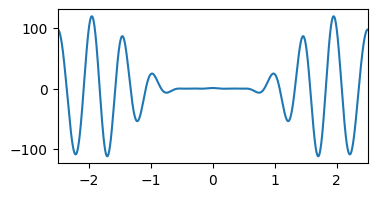

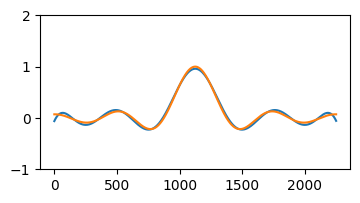

In [17]:
plt.plot(t_test, np.real(y_test))
plt.xlim(-2.5, 2.5)
plt.show()

plt.plot(np.real(y_test)[10000-int(_sinclength/2):10000+int(_sinclength/2)])
plt.plot(_sinc)
plt.ylim(-1, 2)
plt.show()

##### plot and save

###### plot it if you want

In [18]:
# Compute the FFT
dt=1/realinvbw

frequencies     = np.fft.fftfreq(len(y_test), d=dt)
frequencies2    = np.fft.fftfreq(len(y_test2), d=dt)
freq2           = np.fft.fftfreq(len(_sinc), d=dt)

fplot = np.abs(np.fft.fft(np.real(y_test)))
fplot2 = np.abs(np.fft.fft(np.real(y_test2)))
splot = np.abs(np.fft.fft(_sinc))

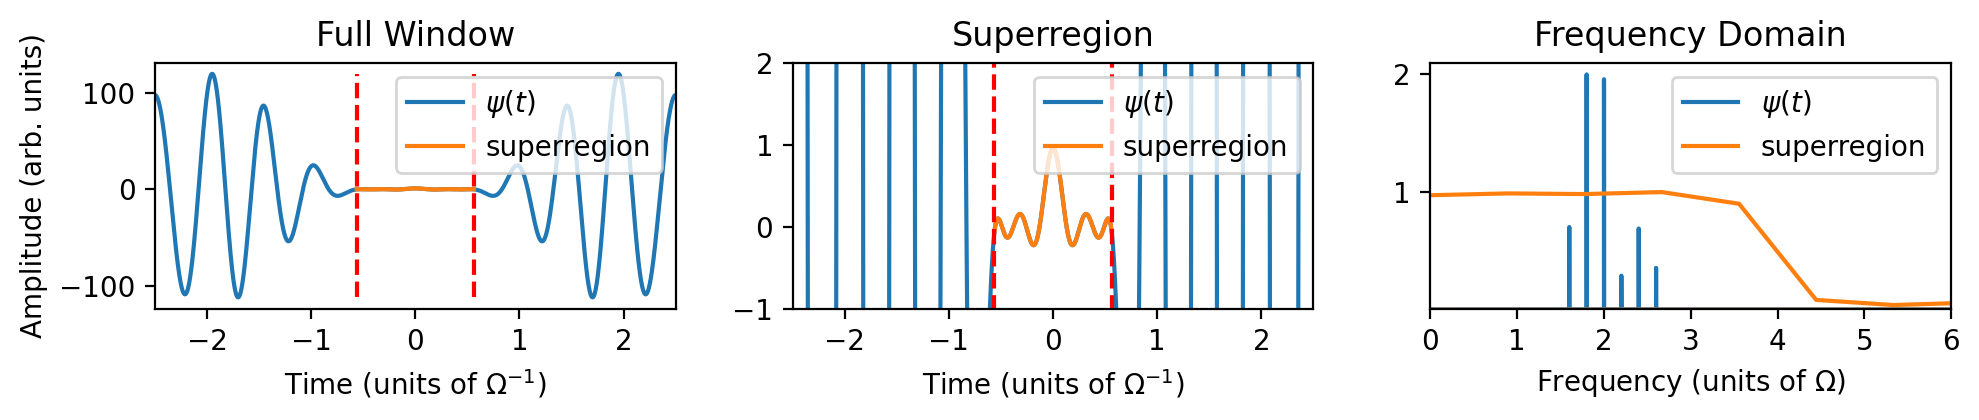

In [20]:
# why *9/8? because the whloe wave is 10,000 time steps, one inverse bandwidth is 1/5 of that (2000),
# and we fitted to 2250 time steps of the sinc wave. 2250/2000 = 9/8.
# so we fitted to just over one of our inverse bandwidths.
# another way of looking at it: we fitted to 4.5 inverse bandwidths of the sinc, which is four times
# as many inverse bandwidths as the total wave. 4.5/4 = 9/8.

fig, axs = plt.subplots(1, 3, figsize=(10,2.2), dpi=200)

axs[0].plot(t_test, np.real(y_test), label=r'$\psi(t)$')
axs[0].plot(t_test2, np.real(y_test)[10000-int(_sinclength/2):10000+int(_sinclength/2)], label='superregion')
axs[0].vlines([-.5*9/8, .5*9/8], min(np.real(y_test)), max(np.real(y_test)),
              linestyles='dashed', color='r')
axs[0].legend(loc='upper right')
axs[0].set_xlim(-2.5, 2.5)
axs[0].set_xlabel(r'Time (units of $\Omega^{-1}$)')
axs[0].set_ylabel('Amplitude (arb. units)')
axs[0].set_title('Full Window')

axs[1].plot(t_test, np.real(y_test), label=r'$\psi(t)$')
axs[1].plot(t_test2, np.real(y_test)[10000-int(_sinclength/2):10000+int(_sinclength/2)], label='superregion')
axs[1].vlines([-.5*(9/8), .5*(9/8)], min(np.real(y_test)), max(np.real(y_test)),
              linestyles='dashed', color='r')
axs[1].legend(loc='upper right')
axs[1].set_xlim(-2.5, 2.5)
axs[1].set_ylim(-1,2)
axs[1].set_xlabel(r'Time (units of $\Omega^{-1}$)')
axs[1].set_title('Superregion')

axs[2].plot(frequencies, fplot*2/np.max(fplot), label=r'$\psi(t)$')
axs[2].plot(frequencies2, fplot2/np.max(fplot2), label='superregion')
# axs[2].plot(frequencies, fplot, label=r'$\psi(t)$')
# axs[2].plot(frequencies2, fplot2, label='superregion')
axs[2].legend(loc='upper right')
axs[2].set_xlim(0,6)
axs[2].set_ylim(.01, 2.1)
axs[2].set_xlabel(r'Frequency (units of $\Omega$)')
axs[2].set_title('Frequency Domain')

plt.tight_layout()
plt.show()

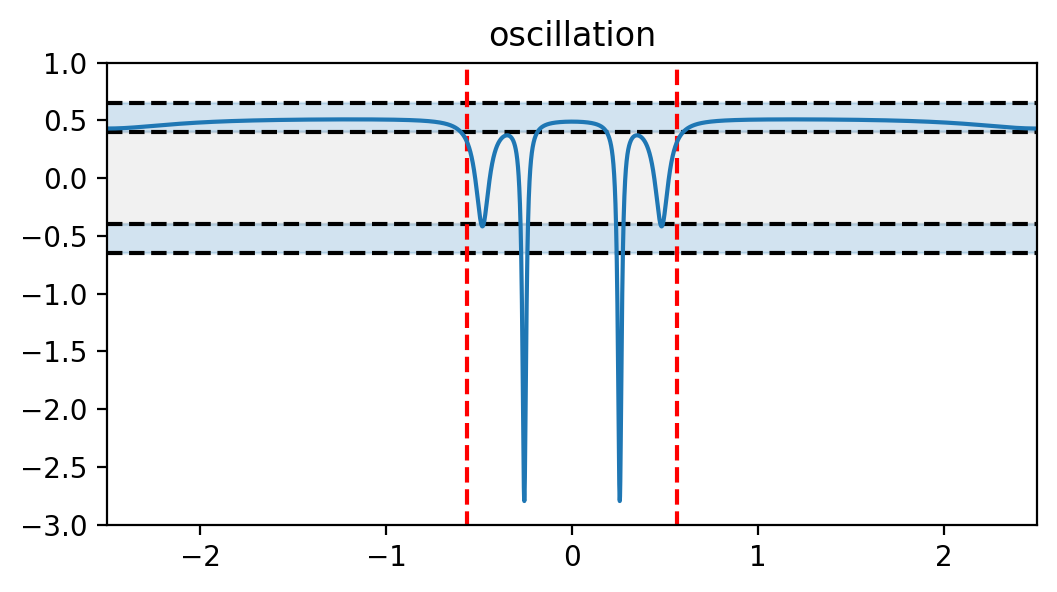

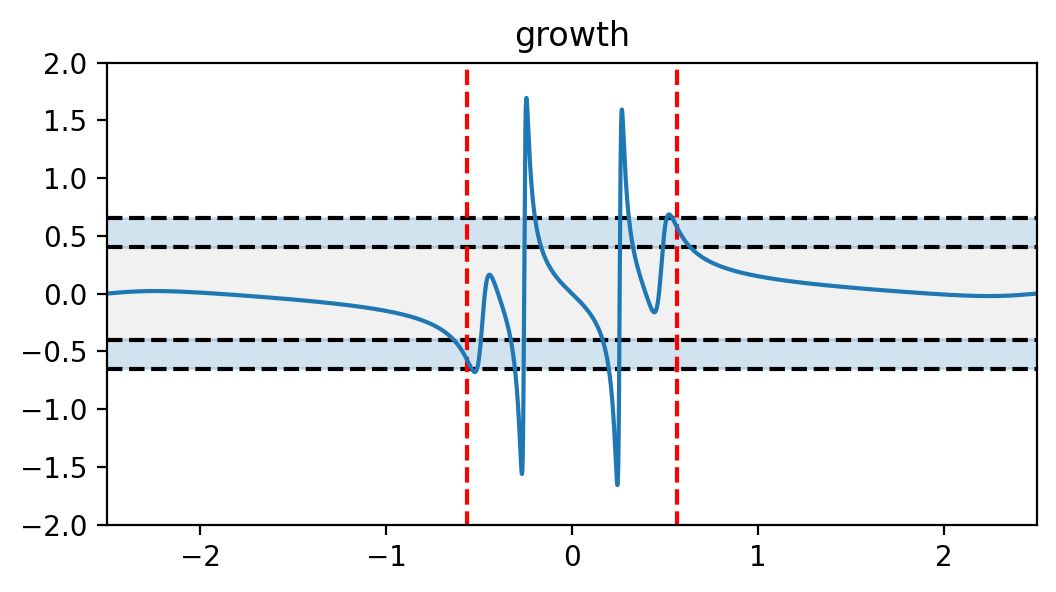

In [21]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (6,3)

plt.title('oscillation')
plt.fill_between(t_test[:-1], -.65, -.4, alpha=.2, color='tab:blue')
plt.fill_between(t_test[:-1], .4, .65, alpha=.2, color='tab:blue')
plt.fill_between(t_test[:-1], -.4, .4, alpha=.1, color='tab:gray')
plt.hlines((-.65, -.4, .4, .65), -2.5, 2.5, linestyles='dashed', color='black')
plt.vlines([-.5*(9/8), .5*(9/8)], min(np.real(y_test)), max(np.real(y_test)),
              linestyles='dashed', color='r')
plt.plot(t_test[:-1], np.diff(np.unwrap(np.angle(y_test)))*invbw/(2*np.pi), color='tab:blue')
plt.xlim(-2.5, 2.5)
plt.ylim(-3, 1)
plt.show()

plt.title('growth')
plt.fill_between(t_test[:-1], -.65, -.4, alpha=.2, color='tab:blue')
plt.fill_between(t_test[:-1], .4, .65, alpha=.2, color='tab:blue')
plt.fill_between(t_test[:-1], -.4, .4, alpha=.1, color='tab:gray')
plt.hlines((-.65, -.4, .4, .65), -2.5, 2.5, linestyles='dashed', color='black')
plt.vlines([-.5*(9/8), .5*(9/8)], min(np.real(y_test)), max(np.real(y_test)),
              linestyles='dashed', color='r')
plt.plot(t_test[:-1], np.diff(np.abs(y_test))*invbw/(np.abs(y_test)[:-1]*2*np.pi), color='tab:blue')
plt.xlim(-2.5, 2.5)
plt.ylim(-2, 2)
plt.show()

###### save it if you want

In [ ]:
np.savetxt('wave.csv', np.real(y_test))

## import and process lab data

### iterative test

In [ ]:
# get ready to store all the waves in a big array
'''
just changed this in two meaningful ways:
  - only processing the real portion of the fft should make the iffts all phase-aligned
  - removing all negative frequencies makes the ifft a complex wave, so we can use all
    the benefits of superoscillation and supergrowth analysis
'''
def get_reconstructions(arr, count, cyclen, N, numcycles, printpeaks=True):
    wavesarr    = [np.zeros(cyclen, dtype=np.complex128) for i in range(count)]
    for i in range(count):
        # pick the next cycle in the series
        cycle   = arr[i*cyclen*numcycles:(i+1)*cyclen*numcycles]
        sc_fft  = np.fft.fft(cycle)

        # helps zero out troublesome low frequencies that sometimes have too large of amplitudes
        sc_fft[:7] = 0
        # sc_fft[-7:] = 0

        # find locations of target frequencies. this assumes each frequency is not drowned in noise
        peaks   = np.sort(np.argsort(np.abs(sc_fft))[-N*2:])[:N]
        if (i%10 == 0) and (printpeaks):
            print(peaks)

        # # filter out frequencies we know we don't need
        # for j in range(len(sc_fft)):
        #     if j not in peaks:
        #         sc_fft[j] = 0

        mask = np.zeros_like(sc_fft, dtype=bool)
        mask[peaks] = True

        # Zero out elements not in peaks
        sc_fft[~mask] = 0

        # return the signal to time domain and save in the 2D array
        wavesarr[i] = np.real(np.fft.ifft(sc_fft))
    return wavesarr

In [ ]:
# process 100 different cycles by spectrally filtering each individually
# and store them in a new 2D array

# variable dump
_sinclength = 2250
_sincwidth  = 4.5
N           = 6
filelen     = 10000000
cyclelen    = 10000
cyclewidth  = 20
superstart  = int(cyclelen/2)-int(_sinclength/2)
spread      = int(_sinclength/2)

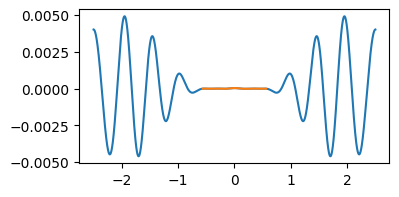

In [ ]:
# simulated wave to compare lab results to

cntr            = int(cyclelen/2)
sim_one_cycle   = np.copy(np.real(y_wave[int(cyclelen/2):cyclelen+int(cyclelen/2)]))/24300
sim_one_cycle  -= np.mean(sim_one_cycle)
sim_super       = sim_one_cycle[cntr-spread:cntr+spread]
sim_super      -= np.mean(sim_super)
t_one_cycle     = np.linspace(-2.5, 2.5, cyclelen)

plt.plot(t_one_cycle, sim_one_cycle)
plt.plot(t_wave2, sim_super)
plt.show()

In [ ]:
# get the data from the file. maybe we make this iterative for tests

filepath    = '/content/drive/MyDrive/Chapman/Research/RADAR/Derek/Reconstructing_Superoscillations/6peaks/400kHz/'
filed       = pd.read_csv(filepath+'6_10mV_8mV_0ft.csv')

In [ ]:
start       = 1163
data        = np.array(filed['CH1V'])[start:start+filelen]
wavecount   = 10
mid         = int(cyclelen/2)
numcycles   = 10

In [ ]:
fullarr   = get_reconstructions(data, wavecount, cyclelen, N, numcycles)
superarr  = [fullarr[i][mid-spread:mid+spread] for i in range(wavecount)]
for i in range(wavecount):
    fullarr[i] -= np.mean(superarr[i])

[ 80  90 100 110 120 130]


In [ ]:
# 1163
_0ft        = fullarr
super_0ft   = superarr

In [ ]:
# 1110
_10ft       = fullarr
super_10ft  = superarr

In [ ]:
# 1110
_20ft       = fullarr
super_20ft  = superarr

In [ ]:
# 10
_30ft       = fullarr
super_30ft  = superarr

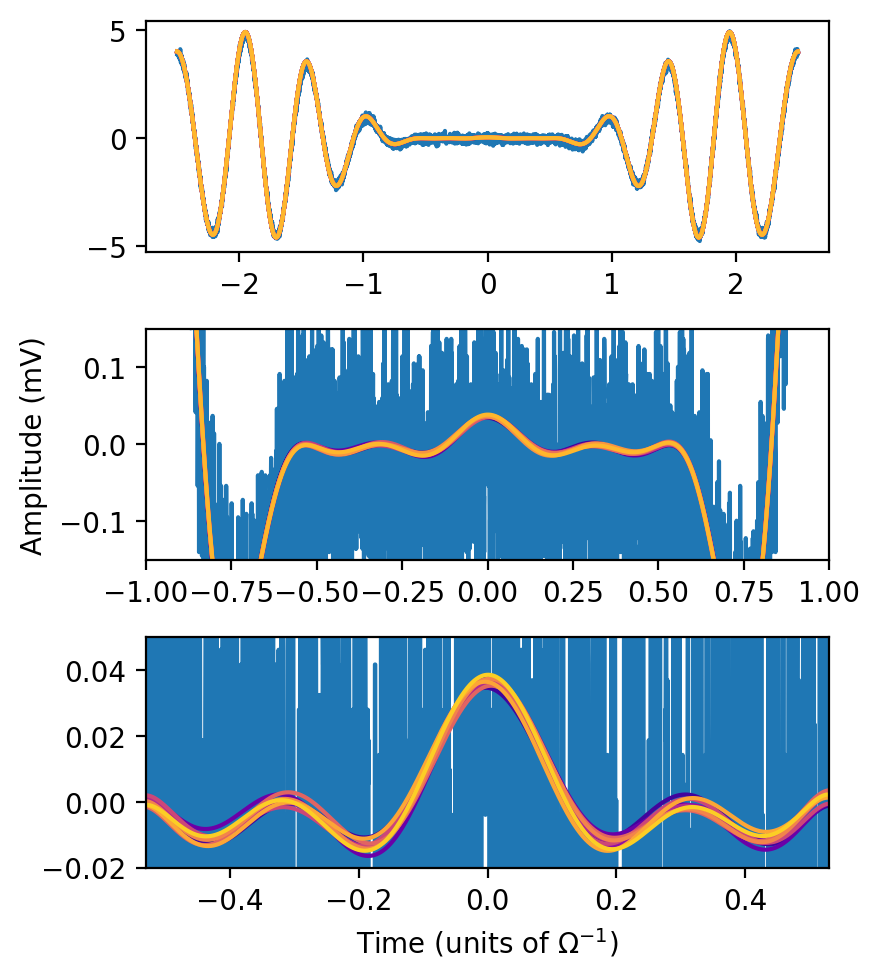

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(4.5,5), dpi=200)

for i in range(3):
    axs[i].plot(t_one_cycle, data[:cyclelen]*1050+.08)
    # axs[i].legend(loc='upper right')

for i in range(len(_0ft)):
    axs[0].plot(t_one_cycle, _0ft[i][:cyclelen]*2000, color=mpl.cm.plasma(i/(wavecount*1.07)))
    axs[1].plot(t_one_cycle, _0ft[i][:cyclelen]*2000, color=mpl.cm.plasma(i/(wavecount*1.07)))
    axs[2].plot(t_one_cycle, _0ft[i][:cyclelen]*2000, color=mpl.cm.plasma(i/wavecount))

axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-.15, .15)
axs[1].set_ylabel('Amplitude (mV)')

axs[2].set_xlim(-.53, .53)
axs[2].set_ylim(-.02, .05)
axs[2].set_xlabel('Time (units of $\Omega^{-1}$)')

plt.tight_layout()
plt.show()

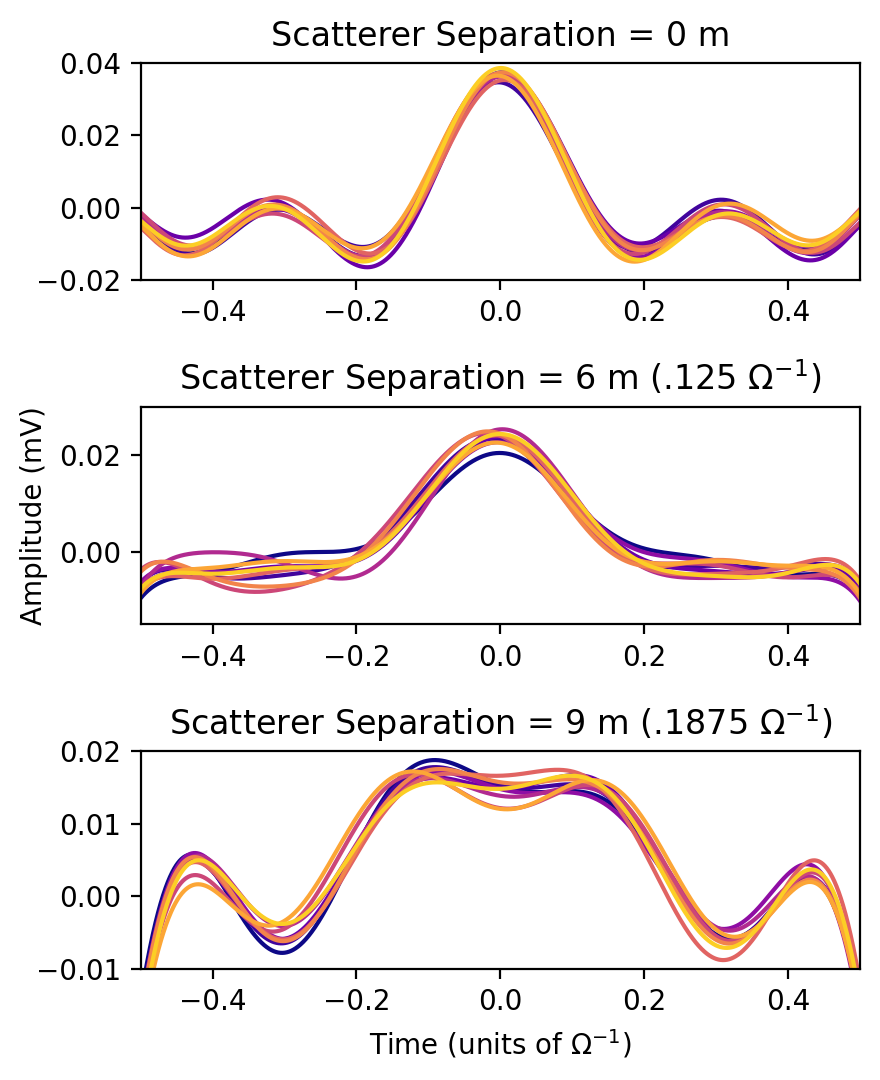

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(4.5,5.5), dpi=200)

newmod = .01
import matplotlib as mpl
k = 0

for i in [_0ft, _20ft, _30ft]:
    # axs[k].plot(t_one_cycle, data[:cyclelen]*1000)
    for j in range(wavecount):
        axs[k].plot(t_one_cycle, i[j][:cyclelen]*2000, color=mpl.cm.plasma(j/wavecount))
        # axs[k].plot(t_one_cycle, i[j][:cyclelen]*1000)
        axs[k].set_xlim(-.5, .5)
        axs[k].set_ylim((-2+.5*k)*newmod, (4-k)*newmod)
    k += 1
axs[2].set_xlabel('Time (units of $\Omega^{-1}$)')
axs[1].set_ylabel('Amplitude (mV)')
axs[0].set_title('Scatterer Separation = 0 m')
axs[1].set_title(r'Scatterer Separation = 6 m (.125 $\Omega^{-1}$)')
axs[2].set_title(r'Scatterer Separation = 9 m (.1875 $\Omega^{-1}$)')
plt.tight_layout()
plt.show()

#### calculate RMSEs

In [ ]:
wavemean    = np.mean(fullarr, axis=0)
supermean   = np.mean(superarr, axis=0)
errs        = []
superrs     = []

for i in range(wavecount):
    err     = np.var(fullarr[i]-wavemean)
    superr  = np.var(superarr[i]-supermean)
    errs.append(err)
    superrs.append(superr)

In [ ]:
print('total wave normalized MSE:', np.mean(errs)/np.var(wavemean))
print('superregion normalized MSE:', np.mean(superrs)/np.var(supermean))

print('total wave normalized RMSE:', np.sqrt(np.mean(errs)/np.var(wavemean)))
print('superregion normalized RMSE:', np.sqrt(np.mean(superrs)/np.var(supermean)))

print('total wave MSE:', np.mean(errs))
print('superregion MSE:', np.mean(superrs))

print('total wave RMSE:', np.sqrt(np.mean(errs)))
print('superregion RMSE:', np.sqrt(np.mean(superrs)))

total wave normalized MSE: 5.163994372636325e-07
superregion normalized MSE: 0.011914561042245829
total wave normalized RMSE: 0.0007186093773835911
superregion normalized RMSE: 0.10915384117036757
total wave MSE: 2.4632142191556806e-12
superregion MSE: 2.1406289119240643e-12
total wave RMSE: 1.569463035294454e-06
superregion RMSE: 1.4630888257122546e-06


# other tests

## use saved data to analyze grid search of parameters for best fit

In [ ]:
pathway = '/content/drive/MyDrive/Chapman/Research/RADAR/Derek/Reconstructing_Superoscillations/'
results = np.loadtxt(pathway+'amp_and_MSE_min_results.csv', delimiter=',')
mins = pd.DataFrame(results)
mins.columns = ['N', 'Omega', 'omega_min', 'amp', 'MSE']

In [ ]:
# some data cleaning
mins['N'] = mins['N'].astype(int)
mins['Omega'] = np.round(mins['Omega'], 3)

mins.head()

,N,Omega,omega_min,amp,MSE
0,3,0.25,0.250,2.074643,0.001041
1,3,0.25,0.251,2.081834,0.001085
2,3,0.25,0.252,2.089039,0.001130
3,3,0.25,0.253,2.096264,0.001177
4,3,0.25,0.254,2.103511,0.001226


In [ ]:
print the re

### amp and MSE as function of Omega (left) and of N (right)

In [ ]:
O25 = mins[mins['Omega'] == .25]
min_mse_N = O25.groupby('N')['MSE'].min()
min_amp_N = O25.groupby('N')['amp'].min()

O5 = mins[mins['Omega'] == .5]
min_mse_N2 = O5.groupby('N')['MSE'].min()
min_amp_N2 = O5.groupby('N')['amp'].min()

In [ ]:
N6 = mins[mins['N'] == 6]
min_mse_O = N6.groupby('Omega')['MSE'].min()
min_amp_O = N6.groupby('Omega')['amp'].min()

N15 = mins[mins['N'] == 11]
min_mse_O2 = N15.groupby('Omega')['MSE'].min()
min_amp_O2 = N15.groupby('Omega')['amp'].min()

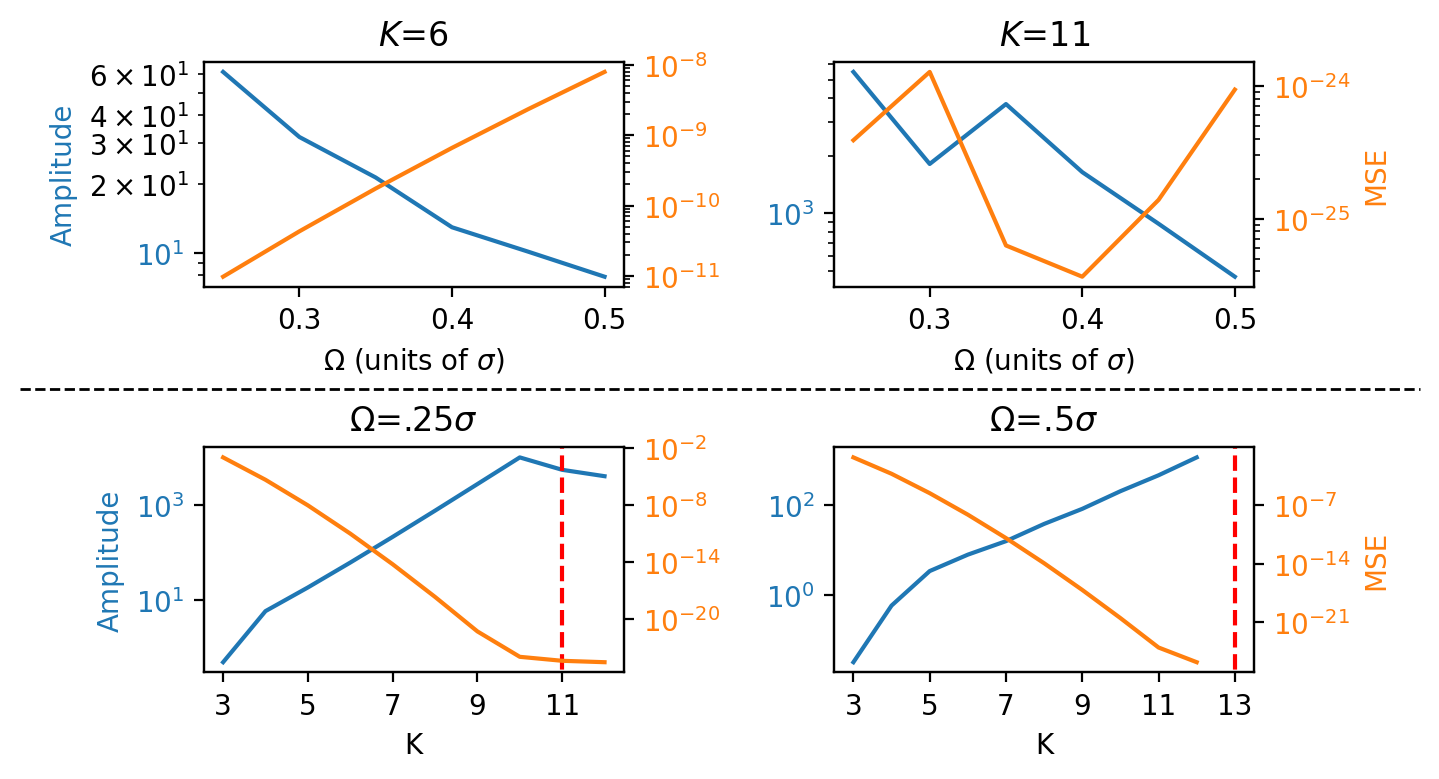

In [ ]:
plt.rcParams['figure.dpi'] = 200
fig = plt.figure(figsize=(7, 4))
gs = fig.add_gridspec(2, 2, height_ratios=[0.5, 0.5])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax1.set_title(r'$K$=6')
ax1.plot(min_amp_O, color='tab:blue', label=r'amp')
ax1.set_xlabel(r'$\Omega$ (units of $\sigma$)')
ax1.set_ylabel('Amplitude', color='tab:blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1a = ax1.twinx()
ax1a.plot(min_mse_O, color='tab:orange', label=r'MSE')
ax1a.tick_params(axis='y', labelcolor='tab:orange', which='major')
ax1a.tick_params(axis='y', which='minor', labelright=False)
ax1a.set_yscale('log')

ax2.set_title(r'$K$=11')
ax2.plot(min_amp_O2, color='tab:blue', label=r'amp')
ax2.set_xlabel(r'$\Omega$ (units of $\sigma$)')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2a = ax2.twinx()
ax2a.plot(min_mse_O2, color='tab:orange', label=r'MSE')
ax2a.tick_params(axis='y', labelcolor='tab:orange', which='major')
ax2a.tick_params(axis='y', which='minor', labelright=False)
ax2a.set_ylabel('MSE', color='tab:orange')
ax2a.set_yscale('log')

ax3.set_title(r'$\Omega$=.25$\sigma$')
ax3.plot(min_amp_N, color='tab:blue', label=r'amp')
ax3.set_xlabel(r'K')
ax3.set_ylabel('Amplitude', color='tab:blue')
ax3.set_yscale('log')
ax3.set_xticks(range(3, 21, 2))
ax3.tick_params(axis='y', labelcolor='tab:blue')
ax3.vlines(11, 0, 3e7, linestyles='dashed', color='red')

ax3a = ax3.twinx()
ax3a.plot(min_mse_N, color='tab:orange', label=r'MSE')
ax3a.set_yscale('log')
ax3a.tick_params(axis='y', labelcolor='tab:orange')

ax4.set_title(r'$\Omega$=.5$\sigma$')
ax4.plot(min_amp_N2, color='tab:blue', label=r'amp')
ax4.set_xlabel(r'K')
ax4.set_yscale('log')
ax4.set_xticks(range(3, 21, 2))
ax4.tick_params(axis='y', labelcolor='tab:blue')
ax4.vlines(13, 0, 1e5, linestyles='dashed', color='red')

ax4a = ax4.twinx()
ax4a.plot(min_mse_N2, color='tab:orange', label=r'MSE')
ax4a.set_ylabel('MSE', color='tab:orange')
ax4a.set_yscale('log')
ax4a.tick_params(axis='y', labelcolor='tab:orange')

line = Line2D([0, 1], [0.5, 0.5], transform=fig.transFigure, color="black", linestyle="--", linewidth=1)
fig.add_artist(line)

plt.tight_layout()
plt.show()